In [18]:
import mujoco
mjcf_path = "../models/ur10/ur10.xml"
urdf_path = "../models/ur10/ur10.urdf"
mj_model = mujoco.MjModel.from_xml_path(urdf_path)

# 2. Zapisujemy go jako natywny plik MuJoCo (MJCF)
mujoco.mj_saveLastXML(mjcf_path, mj_model)

In [1]:
from optimal.PDController import PDController
from optimal.Visualizer import Visualizer
import pinocchio as pin
import numpy as np
import mujoco

mjcf_path = "../models/ur10/ur10.xml"
urdf_path = "../models/ur10/ur10.urdf"
robot_mj_model = mujoco.MjModel.from_xml_path(mjcf_path)
robot_pin_model = pin.buildModelFromUrdf(urdf_path)

kp = np.array([400.0, 800.0, 400.0, 100.0, 4.0, 1.0])
kd = np.array([40.0,  80.0,  40.0,  10.0,  .4,  .1])
torque_limits = np.array([330.0, 330.0, 150.0, 56.0, 56.0, 56.0])
controller = PDController(robot_pin_model, kp=kp, kd=kd, torque_limits=torque_limits)

DT = robot_mj_model.opt.timestep
q_start = pin.neutral(robot_pin_model)
q_target = np.array([0.7, -1.2, 1.5, -0.8, 1.5, 0.5])
xs, us = controller.compute_control(x_start=q_start, x_goal=q_target, horizon=1500, control_dt=DT)

robot_mj_data = mujoco.MjData(robot_mj_model)
viewer = Visualizer(robot_mj_model, robot_mj_data)
viewer.setup_camera(lookat=np.array([0.0, 0.0, 0.7]), distance=3.5, azimuth=90, elevation=-30)
# viewer.visualize(mode="position", vector=xs, dt=DT)

In [5]:
xs, us = controller.compute_control(x_start=q_start, x_goal=q_target, horizon=1500, control_dt=DT, alpha=0.5)
robot_mj_data.qpos[:] = q_start
robot_mj_data.qvel[:] = 0.0
mujoco.mj_forward(robot_mj_model, robot_mj_data)
x_pos = viewer.visualize(mode="control", vector=us, dt=DT)


In [ ]:
robot_mj_data.qpos[:] = q_start
robot_mj_data.qvel[:] = 0.0
us = np.array(us)
mujoco.mj_forward(robot_mj_model, robot_mj_data)
x_pos = viewer.visualize(mode="control", vector=us, dt=DT)


(1500, 6)


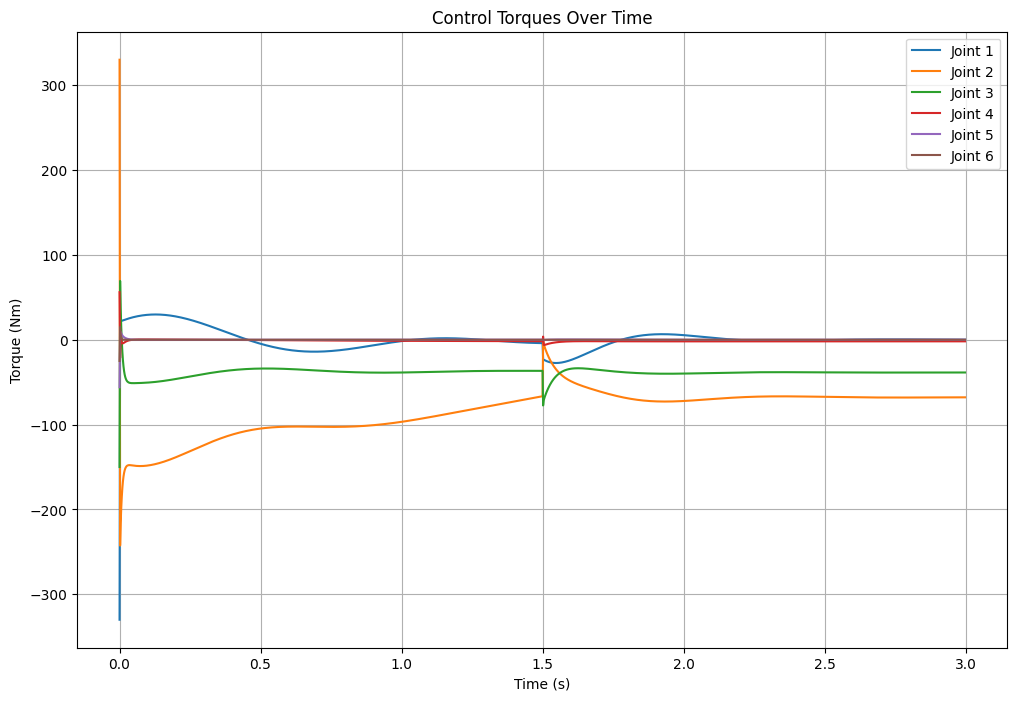

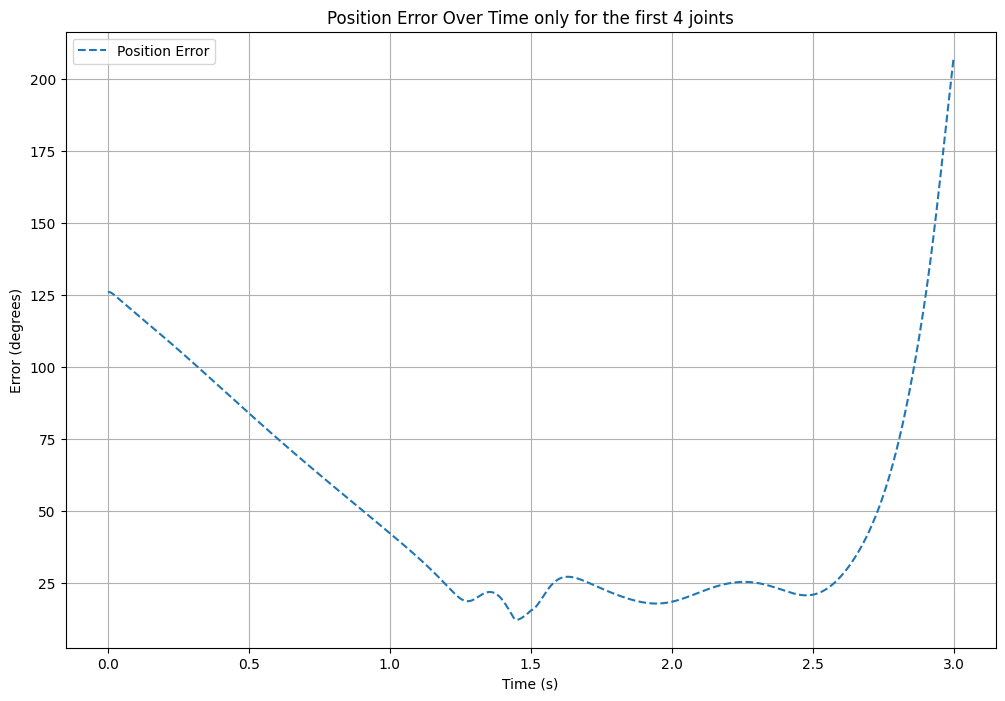

In [6]:
import matplotlib.pyplot as plt
time = np.arange(len(us)) * DT
plt.figure(figsize=(12, 8))
us = np.array(us)  # Convert list of control inputs to a NumPy array
for i in range(us.shape[1]):
    plt.plot(time, us[:, i], label=f'Joint {i+1}')
q_arr = np.full_like(x_pos, q_target)  # Create an array of the same shape as qpos filled with q_target
x_pos = np.array(x_pos)
error = np.linalg.norm((x_pos[:,:4] - q_arr[:,:4])*180/np.pi, axis=1)
plt.title('Control Torques Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(12, 8))
plt.plot(time, error, label='Position Error', linestyle='--')
plt.title('Position Error Over Time only for the first 4 joints')
plt.xlabel('Time (s)')
plt.ylabel('Error (degrees)')
plt.legend()
plt.grid()
plt.show()

In [9]:
import crocoddyl
import pinocchio
import numpy as np

class DifferentialFreeFwdDynamicsModelDerived(
    crocoddyl.DifferentialActionModelAbstract
):
    def __init__(self, state, actuationModel, costModel):
        crocoddyl.DifferentialActionModelAbstract.__init__(
            self, state, actuationModel.nu, costModel.nr
        )
        self.actuation = actuationModel
        self.costs = costModel
        self.enable_force = True
        self.armature = np.matrix(np.zeros(0))

    def calc(self, data, x, u=None):
        if u is None:
            q, v = x[: self.state.nq], x[-self.state.nv :]
            pinocchio.computeAllTerms(self.state.pinocchio, data.pinocchio, q, v)
            self.costs.calc(data.costs, x)
            data.cost = data.costs.cost
        else:
            q, v = x[: self.state.nq], x[-self.state.nv :]
            self.actuation.calc(data.actuation, x, u)
            tau = data.actuation.tau
            # Computing the dynamics using ABA or manually for armature case
            if self.enable_force:
                data.xout[:] = pinocchio.aba(
                    self.state.pinocchio, data.pinocchio, q, v, tau
                )
            else:
                pinocchio.computeAllTerms(self.state.pinocchio, data.pinocchio, q, v)
                data.M = data.pinocchio.M
                if self.armature.size == self.state.nv:
                    data.M[range(self.state.nv), range(self.state.nv)] += self.armature
                data.Minv = np.linalg.inv(data.M)
                data.xout[:] = np.dot(data.Minv, (tau - data.pinocchio.nle))
            # Computing the cost value and residuals
            pinocchio.forwardKinematics(self.state.pinocchio, data.pinocchio, q, v)
            pinocchio.updateFramePlacements(self.state.pinocchio, data.pinocchio)
            self.costs.calc(data.costs, x, u)
            data.cost = data.costs.cost

    def calcDiff(self, data, x, u=None):
        if u is None:
            self.costs.calcDiff(data.costs, x)
        else:
            nq, nv = self.state.nq, self.state.nv
            q, v = x[:nq], x[-nv:]
            # Computing the actuation derivatives
            self.actuation.calcDiff(data.actuation, x, u)
            tau = data.actuation.tau
            # Computing the dynamics derivatives
            if self.enable_force:
                pinocchio.computeABADerivatives(
                    self.state.pinocchio, data.pinocchio, q, v, tau
                )
                ddq_dq = data.pinocchio.ddq_dq
                ddq_dv = data.pinocchio.ddq_dv
                data.Fx[:, :] = np.hstack([ddq_dq, ddq_dv]) + np.dot(
                    data.pinocchio.Minv, data.actuation.dtau_dx
                )
                data.Fu[:, :] = np.dot(data.pinocchio.Minv, data.actuation.dtau_du)
            else:
                pinocchio.computeRNEADerivatives(
                    self.state.pinocchio, data.pinocchio, q, v, data.xout
                )
                ddq_dq = np.dot(
                    data.Minv, (data.actuation.dtau_dx[:, :nv] - data.pinocchio.dtau_dq)
                )
                ddq_dv = np.dot(
                    data.Minv, (data.actuation.dtau_dx[:, nv:] - data.pinocchio.dtau_dv)
                )
                data.Fx[:, :] = np.hstack([ddq_dq, ddq_dv])
                data.Fu[:, :] = np.dot(data.Minv, data.actuation.dtau_du)
            # Computing the cost derivatives
            self.costs.calcDiff(data.costs, x, u)

    def createData(self):
        data = DifferentialFreeFwdDynamicsDataDerived(self)
        return data

    def set_armature(self, armature):
        if armature.size is not self.state.nv:
            print("The armature dimension is wrong, we cannot set it.")
        else:
            self.enable_force = False
            self.armature = armature.T


class DifferentialFreeFwdDynamicsDataDerived(crocoddyl.DifferentialActionDataAbstract):
    def __init__(self, model):
        crocoddyl.DifferentialActionDataAbstract.__init__(self, model)
        self.pinocchio = pinocchio.Model.createData(model.state.pinocchio)
        self.multibody = crocoddyl.DataCollectorMultibody(self.pinocchio)
        self.actuation = model.actuation.createData()
        self.costs = model.costs.createData(self.multibody)
        self.costs.shareMemory(self)
        self.Minv = None

In [10]:
class DifferentialFreeFwdDynamicsModelDerived(
    crocoddyl.DifferentialActionModelAbstract
):
    def __init__(self, state, actuationModel, costModel):
        crocoddyl.DifferentialActionModelAbstract.__init__(
            self, state, actuationModel.nu, costModel.nr
        )
        self.actuation = actuationModel
        self.costs = costModel
        self.enable_force = True
        self.armature = np.matrix(np.zeros(0))

    def calc(self, data, x, u=None):
        if u is None:
            q, v = x[: self.state.nq], x[-self.state.nv :]
            pin.computeAllTerms(self.state.pinocchio, data.pinocchio, q, v)
            self.costs.calc(data.costs, x)
            data.cost = data.costs.cost
        else:
            q, v = x[: self.state.nq], x[-self.state.nv :]
            self.actuation.calc(data.actuation, x, u)
            tau = data.actuation.tau
            # Computing the dynamics using ABA or manually for armature case
            if self.enable_force:
                data.xout[:] = pin.aba(
                    self.state.pinocchio, data.pinocchio, q, v, tau
                )
            else:
                pin.computeAllTerms(self.state.pinocchio, data.pinocchio, q, v)
                data.M = data.pinocchio.M
                if self.armature.size == self.state.nv:
                    data.M[range(self.state.nv), range(self.state.nv)] += self.armature
                data.Minv = np.linalg.inv(data.M)
                data.xout[:] = np.dot(data.Minv, (tau - data.pinocchio.nle))
            # Computing the cost value and residuals
            # Note: No Cartesian kinematics computations are needed when using
            # only configuration space (joint space) costs.
            self.costs.calc(data.costs, x, u)
            data.cost = data.costs.cost

    def calcDiff(self, data, x, u=None):
        if u is None:
            self.costs.calcDiff(data.costs, x)
        else:
            nq, nv = self.state.nq, self.state.nv
            q, v = x[:nq], x[-nv:]
            # Computing the actuation derivatives
            self.actuation.calcDiff(data.actuation, x, u)
            tau = data.actuation.tau
            # Computing the dynamics derivatives
            if self.enable_force:
                pin.computeABADerivatives(
                    self.state.pinocchio, data.pinocchio, q, v, tau
                )
                ddq_dq = data.pinocchio.ddq_dq
                ddq_dv = data.pinocchio.ddq_dv
                data.Fx[:, :] = np.hstack([ddq_dq, ddq_dv]) + np.dot(
                    data.pinocchio.Minv, data.actuation.dtau_dx
                )
                data.Fu[:, :] = np.dot(data.pinocchio.Minv, data.actuation.dtau_du)
            else:
                pin.computeRNEADerivatives(
                    self.state.pinocchio, data.pinocchio, q, v, data.xout
                )
                ddq_dq = np.dot(
                    data.Minv, (data.actuation.dtau_dx[:, :nv] - data.pinocchio.dtau_dq)
                )
                ddq_dv = np.dot(
                    data.Minv, (data.actuation.dtau_dx[:, nv:] - data.pinocchio.dtau_dv)
                )
                data.Fx[:, :] = np.hstack([ddq_dq, ddq_dv])
                data.Fu[:, :] = np.dot(data.Minv, data.actuation.dtau_du)
            # Computing the cost derivatives
            self.costs.calcDiff(data.costs, x, u)

    def createData(self):
        data = DifferentialFreeFwdDynamicsDataDerived(self)
        return data

    def set_armature(self, armature):
        if armature.size is not self.state.nv:
            print("The armature dimension is wrong, we cannot set it.")
        else:
            self.enable_force = False
            self.armature = armature.T

In [11]:
q0 = pin.neutral(robot_pin_model)
x0 = np.concatenate([q0, np.zeros(robot_pin_model.nv)])

# Create the cost functions
# target = np.array([0.4, 0.0, 0.4])
# target = np.array([0.6, 0.2, 0.2])
q_start = pin.neutral(robot_pin_model)
q_target = np.array([0.7, -1.2, 1.5, -0.8, 1.5, 0.5])

robot_data = robot_pin_model.createData()
pinocchio.forwardKinematics(robot_pin_model, robot_data, q0)
pinocchio.updateFramePlacements(robot_pin_model, robot_data)
state = crocoddyl.StateMultibody(robot_pin_model)
# framePlacementResidual = crocoddyl.ResidualModelFramePlacement(
#     state, robot_pin_model.getFrameId("wrist_3_link"), pin.SE3(target_rot, target_pos),
# )
framePlacementResidual = crocoddyl.ResidualModelState(state, np.concatenate([q_target, np.zeros(robot_pin_model.nv)]))
goalTrackingCost = crocoddyl.CostModelResidual(state, framePlacementResidual)
xRegCost = crocoddyl.CostModelResidual(state, crocoddyl.ResidualModelState(state))
uRegCost = crocoddyl.CostModelResidual(state, crocoddyl.ResidualModelControl(state))

# Create cost model per each action model
runningCostModel = crocoddyl.CostModelSum(state)
terminalCostModel = crocoddyl.CostModelSum(state)

# Then let's added the running and terminal cost functions
runningCostModel.addCost("gripperPose", goalTrackingCost, 1e2)
runningCostModel.addCost("stateReg", xRegCost, 1e-4)
runningCostModel.addCost("ctrlReg", uRegCost, 1e-7)
terminalCostModel.addCost("gripperPose", goalTrackingCost, 1e5)
terminalCostModel.addCost("stateReg", xRegCost, 1e-4)
terminalCostModel.addCost("ctrlReg", uRegCost, 1e-7)

# Running and terminal action models
DT = robot_mj_model.opt.timestep
actuationModel = crocoddyl.ActuationModelFull(state)
runningModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuationModel, runningCostModel
    ),
    DT,
)
terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuationModel, terminalCostModel
    ),
    0.0,
)

In [16]:
import time
# For this optimal control problem, we define 250 knots (or running action
# models) plus a terminal knot
T = 3000
print(len(x0[:6]))
print(x0)
u0 = np.zeros(actuationModel.nu * T)
robot_mj_data = mujoco.MjData(robot_mj_model)
print(robot_mj_data.xpos[mujoco.mj_name2id(robot_mj_model, mujoco.mjtObj.mjOBJ_BODY, "wrist_3_link")])
# compute xyz position of wrist_3_link using joint positions and forward kinematics
robot_data = robot_pin_model.createData()
pinocchio.forwardKinematics(robot_pin_model, robot_data, q0)
pinocchio.updateFramePlacements(robot_pin_model, robot_data)
frame_id = robot_pin_model.getFrameId("wrist_3_link")
wrist_pos = robot_data.oMf[frame_id].translation
print("wrist_3_link position (Pinocchio FK):", wrist_pos)

problem = crocoddyl.ShootingProblem(x0, [runningModel] * T, terminalModel)

xs, us = controller.compute_control(x_start=q_start, x_goal=q_target, horizon=T, control_dt=DT)
# Creating the DDP solver for this OC problem, defining a logger
solver = crocoddyl.SolverFDDP(problem)
solver.solve(xs, us, 100, False)
log = crocoddyl.CallbackLogger()
pinocchio.forwardKinematics(robot_pin_model, robot_data, robot_mj_data.qpos)

print(robot_mj_data.ctrl)
viewer = Visualizer(robot_mj_model, robot_mj_data)
viewer.setup_camera(lookat=np.array([0.0, 0.0, 0.7]), distance=3.5, azimuth=90, elevation=-30)
robot_mj_data.qpos = pin.neutral(robot_pin_model)
robot_mj_data.qvel[:] = 0.0
mujoco.mj_forward(robot_mj_model, robot_mj_data)
viewer.visualize(mode="control", vector=solver.us, dt=DT)

# print position of wrist_3_link
print(robot_mj_data.xpos[mujoco.mj_name2id(robot_mj_model, mujoco.mjtObj.mjOBJ_BODY, "wrist_3_link")])

pinocchio.forwardKinematics(robot_pin_model, robot_data, robot_mj_data.qpos)
pinocchio.updateFramePlacements(robot_pin_model, robot_data)
frame_id = robot_pin_model.getFrameId("wrist_3_link")
wrist_pos = robot_data.oMf[frame_id].translation
print("wrist_3_link position (Pinocchio FK):", wrist_pos)

6
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0.]
wrist_3_link position (Pinocchio FK): [1.1843   0.256141 0.0116  ]
[0. 0. 0. 0. 0. 0.]
[-0.22958215  0.36477149  0.1721462 ]
wrist_3_link position (Pinocchio FK): [-0.22836949  0.36531135 -0.69617508]


In [53]:
import mujoco, mujoco.viewer
model = mujoco.MjModel.from_xml_path('../models/ur5e/ur5e.urdf')
data = mujoco.MjData(model)
with mujoco.viewer.launch_passive(model, data) as viewer:
    mujoco.mj_step(model, data)
    viewer.sync()
    input("Press Enter to continue...")
mujoco.mj_saveLastXML('../models/robot.xml', model)


ValueError: Error: Error opening file 'wrist1.stl'

In [55]:
from pathlib import Path
import mujoco, mujoco.viewer

urdf = (Path.cwd() / "models" / "ur5e" / "ur5e.urdf").resolve()
if not urdf.exists():
    urdf = (Path.cwd().parent / "models" / "ur5e" / "ur5e.urdf").resolve()

model = mujoco.MjModel.from_xml_path(str(urdf))
data = mujoco.MjData(model)

with mujoco.viewer.launch_passive(model, data) as viewer:
    mujoco.mj_step(model, data)
    viewer.sync()
    input("Press Enter to continue...")

mujoco.mj_saveLastXML(str(urdf.with_suffix(".xml")), model)


In [61]:
import mujoco
model = mujoco.MjModel.from_xml_path('../models/combined.xml')
data = mujoco.MjData(model)
with mujoco.viewer.launch_passive(model, data) as viewer:
    for _ in range(10):
        mujoco.mj_step(model, data)
        viewer.sync()
    input("Press Enter to continue...")


In [7]:
import pinocchio
import mujoco

# 1. Tworzenie MÓZGU (Crocoddyl / Pinocchio)
# Ładujemy czysty model ramienia w formacie URDF
urdf_path = "../models/ur5e/ur5e.urdf"
rmodel = pinocchio.buildModelFromUrdf(urdf_path)

# 2. Tworzenie ŚWIATA (MuJoCo)
# Opcja A: Jeśli symulujesz samo ramię, ładujesz ten sam URDF prosto do MuJoCo
mj_model = mujoco.MjModel.from_xml_path(urdf_path)

# 2. Zapisujemy go jako natywny plik MuJoCo (MJCF)
mujoco.mj_saveLastXML("../models/ur5e/ur5e.xml", mj_model)

print("Konwersja zakończona! Wygenerowano ur5e.xml")

# Opcja B: Jeśli masz złożoną scenę (podłoga, kamery, klocek, stół), 
# ładujesz plik scene.xml, który W SOBIE zawiera (include) plik URDF.
mj_model = mujoco.MjModel.from_xml_path("../models/test_scene.xml")

Konwersja zakończona! Wygenerowano ur5e.xml


ValueError: Error: Error opening file 'mesh/models/ur5e/collision/base.stl'